# Rural India Micro-Loan Default Risk Scoring using Logistic Regression

### Rural India Micro-Loan Default Risk Scoring using Logistic Regression is a fintech-focused machine learning project that builds a binary classification model to predict micro-loan default risk for rural borrowers in India.

## Understanding Data

In [3]:
import pandas as pd

df = pd.read_csv("microloan_rural_india_data.csv")

print(df.head())
print(df.info())
print(df.describe())


   Income_INR  Village_Risk_Score  Loan_Size_INR  Past_Repayment_History  \
0       12687               0.188           9075                       1   
1        9236               0.170          12685                       0   
2       13682               0.511          29596                       1   
3       21194               0.319          52259                       1   
4        8803               0.384          10603                       0   

   Default  
0        0  
1        0  
2        0  
3        1  
4        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Income_INR              10000 non-null  int64  
 1   Village_Risk_Score      10000 non-null  float64
 2   Loan_Size_INR           10000 non-null  int64  
 3   Past_Repayment_History  10000 non-null  int64  
 4   Default                 10000 non-n

## Checking class balance

In [4]:
df["Default"].value_counts(normalize=True)


Default
0    0.6088
1    0.3912
Name: proportion, dtype: float64

## EDA

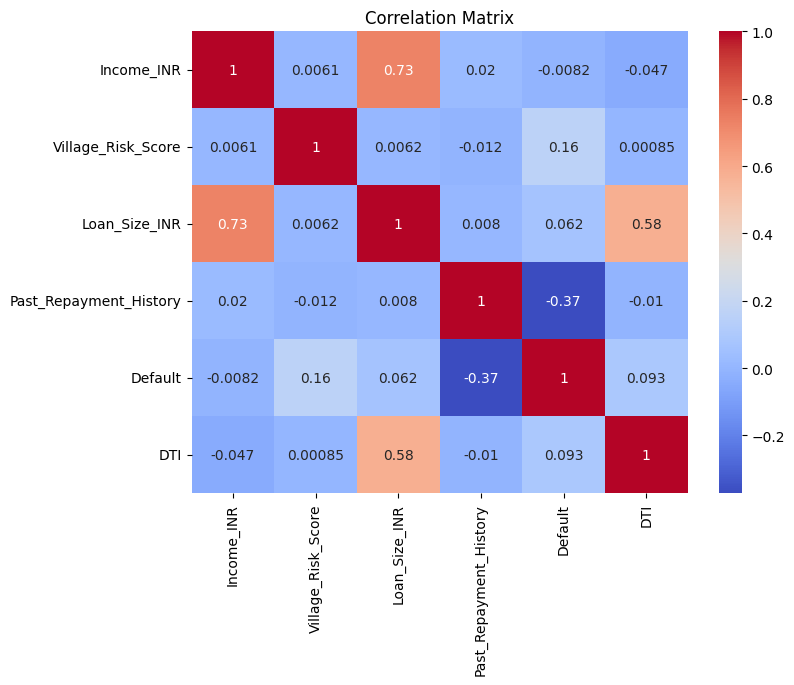

In [ ]:
# Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


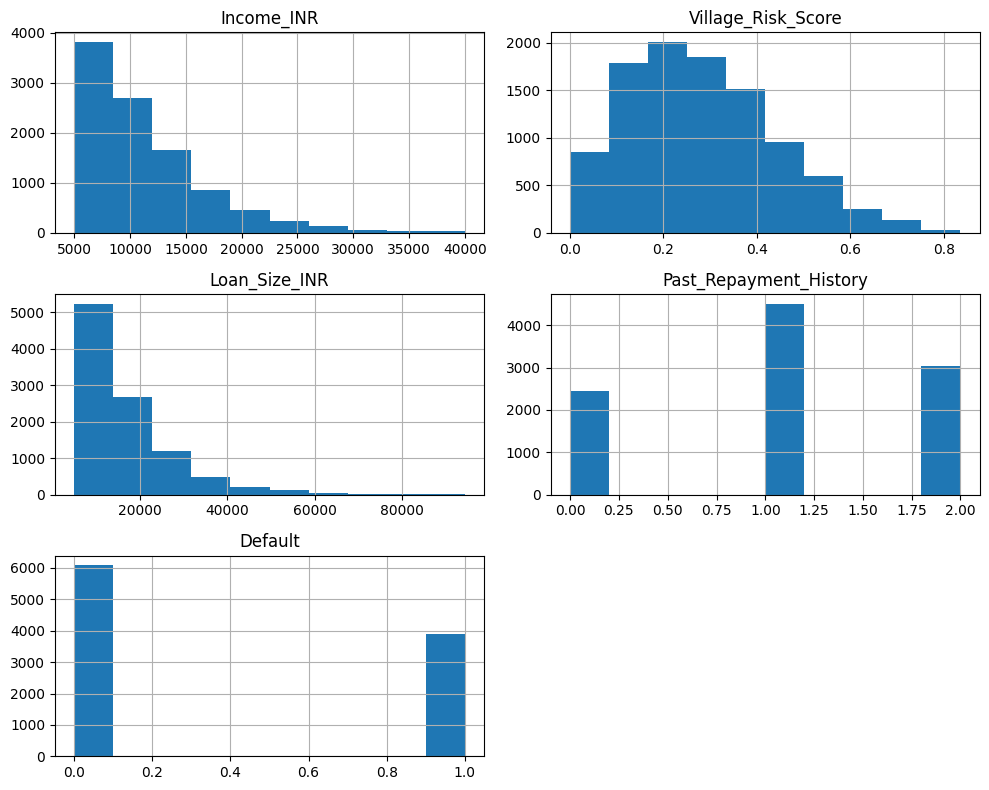

In [ ]:
# Histogram 
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()


## Feature Engineering

In [7]:
# Debt to income ratio
df["DTI"] = df["Loan_Size_INR"] / df["Income_INR"]


In [8]:
from sklearn.preprocessing import StandardScaler

features = ["Income_INR", "Village_Risk_Score",
            "Loan_Size_INR", "Past_Repayment_History", "DTI"]

X = df[features]
y = df["Default"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression()

cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring="roc_auc")

print("Cross Validation ROC-AUC:", cv_scores.mean())


Cross Validation ROC-AUC: 0.7454460151436733


## Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)

print("Feature Coefficients:", model_l1.coef_)


Feature Coefficients: [[-0.25169995  0.40117963  0.31367681 -0.86531031  0.0457964 ]]


In [12]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


## Model Evaluation

In [13]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))


[[984 234]
 [372 410]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.73      0.81      0.76      1218
           1       0.64      0.52      0.58       782

    accuracy                           0.70      2000
   macro avg       0.68      0.67      0.67      2000
weighted avg       0.69      0.70      0.69      2000

Accuracy: 0.697
Precision: 0.6366459627329193
Recall: 0.5242966751918159
F1 Score: 0.5750350631136045


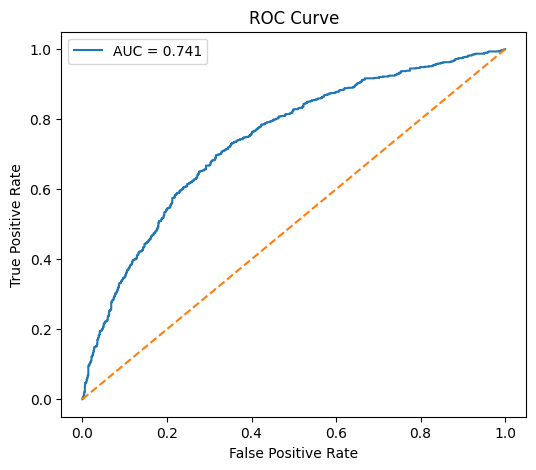

ROC-AUC Score: 0.741279045351274


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)
